# Lecture 3c — Shrinkage, Denoising and Clustering

### The claim on trial

> **"AI fixes the optimiser."**

Lecture 3b left us with a precise diagnosis. Mean-variance optimisation failed not because
the mathematics was wrong but because we inverted a covariance matrix we had estimated badly,
and inversion gives the most influence to the directions we know least about.

So the prescription writes itself. Either **estimate the matrix better**, or **stop inverting
it**. Those two ideas are the whole of this notebook, and both come from machine learning:

| Approach | Idea | Machine learning name for it |
|---|---|---|
| **Shrinkage** | pull the noisy estimate towards a simple, stable target | regularisation |
| **Denoising** | delete the eigenvalues indistinguishable from random | dimensionality reduction |
| **Hierarchical risk parity** | cluster the assets and allocate through the tree | unsupervised learning |

We will do all three with **Riskfolio-Lib**, then judge them the only way that counts: walk
forward through time, rebalance, pay costs, and compare against the naive portfolios that
humiliated the optimiser last time.

The verdict will be more interesting than either "AI wins" or "AI loses".

### What you will be able to do afterwards

1. Use the **Marchenko–Pastur** bound to quantify what fraction of a covariance matrix is
   statistically indistinguishable from noise.
2. Apply **Ledoit–Wolf** and related shrinkage estimators and show what they do to the
   conditioning of the matrix and to the resulting weights.
3. **Denoise** a covariance matrix by clipping its noise eigenvalues.
4. Build **hierarchical risk parity** portfolios, read the dendrogram, and verify that the
   clustering recovers real economic structure.
5. Run a walk-forward horse race with turnover and transaction costs, and explain why the
   *evaluation protocol* changed the answer more than any of the methods did.

---

## 0. Setup

This notebook needs **Riskfolio-Lib**, which brings `cvxpy` with it. On Colab this installs
in a minute or two. On a locked-down university machine it occasionally struggles — if it
does, everything in Sections 1 and 2 still runs, since those use NumPy and scikit-learn only.

In [1]:
# =====================================================================
#  AIRM Lecture 3c — bootstrap.  Run once. (Slowest bootstrap of the course.)
# =====================================================================
import sys, subprocess, urllib.request, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

def _has(p):
    try: __import__({"scikit-learn": "sklearn", "riskfolio-lib": "riskfolio"}.get(p, p)); return True
    except ImportError: return False

def ensure(pkgs):
    missing = [p for p in pkgs if not _has(p)]
    if missing:
        print(f"Installing {', '.join(missing)} ... (this can take a couple of minutes)")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

ensure(["pandas", "numpy", "plotly", "scipy", "scikit-learn"])

HAS_RISKFOLIO = True
try:
    ensure(["riskfolio-lib"])
    import riskfolio as rp
    from riskfolio import AuxFunctions as af
except Exception as e:
    HAS_RISKFOLIO = False
    print(f"Riskfolio-Lib unavailable ({type(e).__name__}). Sections 1-2 still work.")

import numpy as np, pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import plotly.io as pio

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB: pio.renderers.default = "colab"
np.random.seed(3)

AIRM_TEMPLATE = "plotly_white"
AIRM_COLOURS  = ["#1b4965", "#c1121f", "#5fa8d3", "#e09f3e", "#606c38", "#8e7dbe"]
TRADING_DAYS  = 252

DATA_DIR = Path("airm_data"); DATA_DIR.mkdir(exist_ok=True)
SOURCES = {
    "prices.csv":       "https://raw.githubusercontent.com/plotly/datasets/master/all_stocks_5yr.csv",
    "constituents.csv": "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv",
}
def fetch(name):
    path = DATA_DIR / name
    if not path.exists():
        print(f"Downloading {name} ...", end=" ")
        urllib.request.urlretrieve(SOURCES[name], path); print("done")
    return path

_raw = pd.read_csv(fetch("prices.csv"), parse_dates=["date"]).rename(columns={"Name": "ticker"})
_con = pd.read_csv(fetch("constituents.csv"))
prices_all = _raw.pivot_table(index="date", columns="ticker", values="close")
SECTOR = _con.set_index("Symbol")["GICS Sector"].to_dict()

PER_SECTOR = 4
_liq = _raw.groupby("ticker")["volume"].mean()
_elig = [t for t in prices_all.columns if t in SECTOR and prices_all[t].notna().all()]
universe = []
for s in sorted({SECTOR[t] for t in _elig}):
    names = [t for t in _elig if SECTOR[t] == s]
    universe += list(_liq[names].nlargest(PER_SECTOR).index)
universe = sorted(universe, key=lambda t: (SECTOR[t], t))

returns = prices_all[universe].pct_change(fill_method=None).dropna()
N = len(universe)
split_k = int(len(returns) * 0.60)
train, test = returns.iloc[:split_k], returns.iloc[split_k:]

print(f"\nReady. {N} stocks, {len(returns)} days. Riskfolio-Lib: {HAS_RISKFOLIO}")
print(f"TRAIN {len(train)} days | TEST {len(test)} days")


Ready. 44 stocks, 1258 days. Riskfolio-Lib: True
TRAIN 754 days | TEST 504 days


---

## 1. The diagnosis, made precise

How much of our covariance matrix is actually information?

There is a startlingly clean answer. **Random matrix theory** tells us what the eigenvalues of
a correlation matrix look like when the underlying data is *pure noise* — that is, when the
assets are genuinely independent and any structure we see is an accident of finite sampling.
For $N$ assets and $T$ observations, those noise eigenvalues fall inside the
**Marchenko–Pastur** band:

$$\lambda_{\pm} = \left(1 \pm \sqrt{\tfrac{N}{T}}\right)^{2}$$

Any eigenvalue **inside** that band is indistinguishable from randomness. Any eigenvalue
**above** it is real structure.

Let us count.

In [2]:
def mp_band(n_assets, n_obs):
    """Marchenko-Pastur bounds: the range of eigenvalues consistent with pure noise."""
    ratio = np.sqrt(n_assets / n_obs)
    return (1 - ratio) ** 2, (1 + ratio) ** 2


corr_tr = np.corrcoef(train.values.T)
eigs = np.linalg.eigvalsh(corr_tr)[::-1]
T = len(train)
lo, hi = mp_band(N, T)
n_signal = int((eigs > hi).sum())

print(f"Assets N = {N}, observations T = {T},  T/N = {T/N:.1f}")
print(f"Marchenko-Pastur noise band: [{lo:.3f}, {hi:.3f}]\n")
print(f"Eigenvalues ABOVE the band (real structure): {n_signal} of {N}")
print(f"Eigenvalues INSIDE the band (noise)        : {N - n_signal} of {N}")
print(f"\nSix largest eigenvalues: {np.round(eigs[:6], 2)}")
print(f"\nDistinct covariance parameters being estimated: {N*(N+1)//2}")
print(f"Observations available                       : {T}")
print(f"\nSo we are fitting {N*(N+1)//2} numbers to {T} data points, and only {n_signal} "
      f"directions\nout of {N} carry information that survives a noise test.")

Assets N = 44, observations T = 754,  T/N = 17.1
Marchenko-Pastur noise band: [0.575, 1.541]

Eigenvalues ABOVE the band (real structure): 3 of 44
Eigenvalues INSIDE the band (noise)        : 41 of 44

Six largest eigenvalues: [14.96  2.47  2.33  1.4   1.29  1.13]

Distinct covariance parameters being estimated: 990
Observations available                       : 754

So we are fitting 990 numbers to 754 data points, and only 3 directions
out of 44 carry information that survives a noise test.


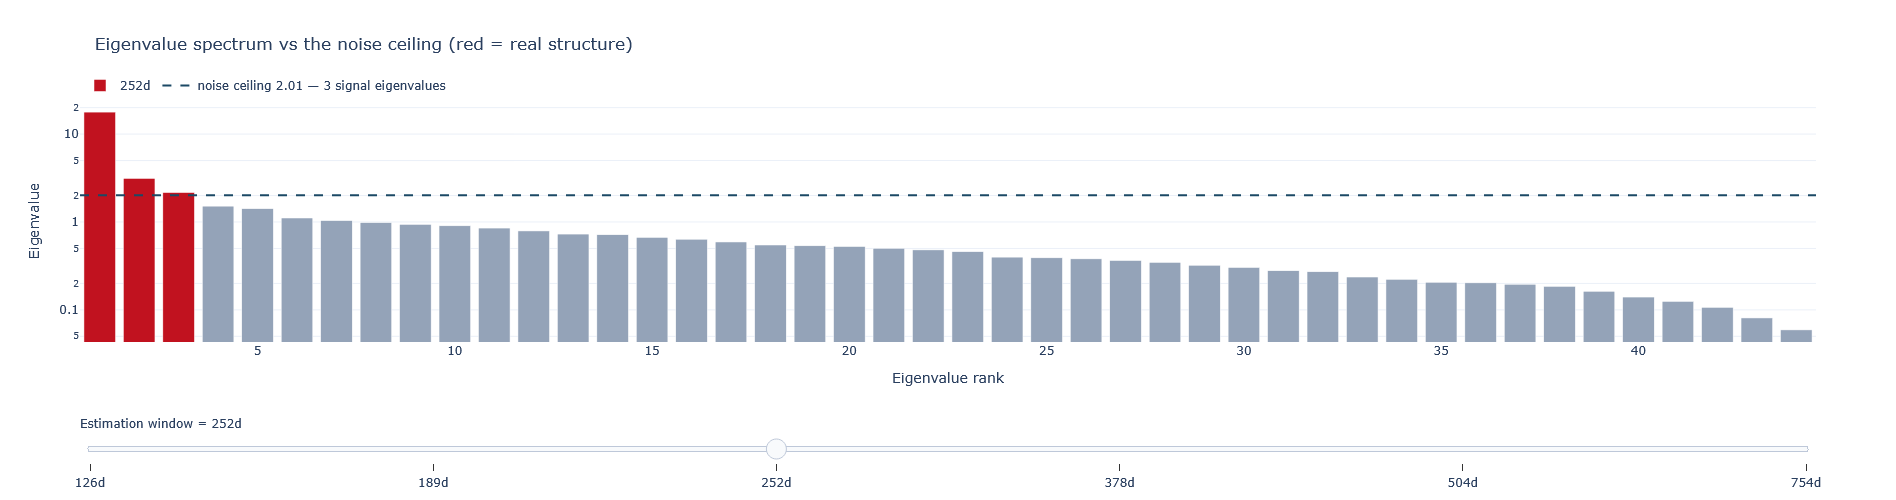

Shorten the window and watch the noise ceiling rise as real factors sink beneath it.
   126 days (T/N =  2.9): ceiling 2.53, 2 signal eigenvalues of 44
   189 days (T/N =  4.3): ceiling 2.20, 2 signal eigenvalues of 44
   252 days (T/N =  5.7): ceiling 2.01, 3 signal eigenvalues of 44
   378 days (T/N =  8.6): ceiling 1.80, 3 signal eigenvalues of 44
   504 days (T/N = 11.5): ceiling 1.68, 3 signal eigenvalues of 44
   754 days (T/N = 17.1): ceiling 1.54, 3 signal eigenvalues of 44


In [3]:
# Show the spectrum against the noise band, and let the student shrink the window.
windows = [126, 189, 252, 378, 504, 754]

fig = go.Figure()
for k, w in enumerate(windows):
    sub = train.iloc[-w:]
    e = np.linalg.eigvalsh(np.corrcoef(sub.values.T))[::-1]
    l_, h_ = mp_band(N, w)
    n_sig = int((e > h_).sum())
    fig.add_trace(go.Bar(x=np.arange(1, N+1), y=e, visible=(w == 252),
                         marker_color=["#c1121f" if v > h_ else "#94a3b8" for v in e],
                         name=f"{w}d", hovertemplate="eigenvalue %{y:.2f}<extra></extra>"))
    fig.add_trace(go.Scatter(x=[0.5, N+0.5], y=[h_, h_], mode="lines", visible=(w == 252),
                             line=dict(color=AIRM_COLOURS[0], width=2, dash="dash"),
                             name=f"noise ceiling {h_:.2f} — {n_sig} signal eigenvalues"))

steps = []
for k, w in enumerate(windows):
    vis = [False] * (2 * len(windows))
    vis[2*k] = vis[2*k+1] = True
    steps.append(dict(label=f"{w}d", method="update", args=[{"visible": vis}]))

fig.update_layout(
    title="Eigenvalue spectrum vs the noise ceiling (red = real structure)",
    template=AIRM_TEMPLATE, height=500, showlegend=True,
    xaxis_title="Eigenvalue rank", yaxis_title="Eigenvalue",
    yaxis_type="log", legend=dict(orientation="h", y=1.12),
    sliders=[dict(active=windows.index(252), pad=dict(t=70),
                  currentvalue=dict(prefix="Estimation window = "), steps=steps)])
fig.show()

print("Shorten the window and watch the noise ceiling rise as real factors sink beneath it.")
for w in windows:
    sub = train.iloc[-w:]
    e = np.linalg.eigvalsh(np.corrcoef(sub.values.T))[::-1]
    _, h_ = mp_band(N, w)
    print(f"  {w:4d} days (T/N = {w/N:4.1f}): ceiling {h_:.2f}, "
          f"{int((e > h_).sum())} signal eigenvalues of {N}")

The largest eigenvalue is about 15 — that is **the market**, the single factor that moves
everything together, and it dwarfs everything else. Two more clear the bar, and they turn out
to be sector effects. Everything from the fourth eigenvalue down is, statistically speaking,
noise.

That is the entire problem in one chart. When Lecture 3b inverted this matrix, the 41 noise
directions did not politely contribute nothing — inversion turned them into the *dominant*
terms, because inversion maps small eigenvalues to large ones.

<details>
<summary><b>Why the market factor swamps everything</b></summary>

A correlation matrix has trace $N$ (ones on the diagonal), so the eigenvalues must sum to
$N = 44$. Our largest alone is about 15 — one third of the total variance in a single
direction. That is the standard picture for equities: a dominant market factor, a handful of
sector factors, and a long tail of idiosyncratic noise.

This is also why Lecture 3a found a diversification floor. The market eigenvalue *cannot* be
diversified away, because every asset loads on it. Portfolio construction can reallocate the
small eigenvalue directions; it cannot remove the big one.

And it explains why $T/N$ matters so much. The noise ceiling is
$(1+\sqrt{N/T})^2$, so with $T/N = 5.7$ (a one-year window on 44 stocks) the ceiling sits at
about 2.0 and even genuine sector factors disappear beneath it. Practitioners using a
one-year lookback on a few hundred names are, by this measure, working with a matrix that is
almost entirely noise.

</details>

---

## 2. Fix one: shrinkage

The idea is almost embarrassingly simple. Our sample matrix $S$ is unbiased but wildly
noisy. A trivial target matrix $F$ — say, "every asset has the same variance and all
correlations are equal" — is heavily biased but very stable. So take a weighted average:

$$\hat{\Sigma} = \delta F + (1-\delta) S$$

Deliberately introduce bias to buy a large reduction in variance. Ledoit and Wolf showed how
to choose $\delta$ optimally in closed form, and the resulting estimator is now standard.

If you have met ridge regression, you have met this idea: accept a little bias to stabilise
an ill-conditioned inversion.

In [4]:
def condition_number(matrix):
    """Ratio of largest to smallest eigenvalue. High = close to singular = dangerous to invert."""
    return np.linalg.cond(matrix)


COV_METHODS = {
    "hist":    "Sample covariance (no shrinkage)",
    "ledoit":  "Ledoit-Wolf shrinkage",
    "oas":     "Oracle Approximating Shrinkage",
    "shrunk":  "Basic shrinkage",
    "fixed":   "Denoised (Marchenko-Pastur clipping)",
    "jlogo":   "J-LoGo (graph-based)",
    "gerber1": "Gerber statistic",
}

if HAS_RISKFOLIO:
    rows = []
    cov_store = {}
    for key, label in COV_METHODS.items():
        p = rp.Portfolio(returns=train)
        p.assets_stats(method_mu="hist", method_cov=key)
        cov_store[key] = p.cov.values.copy()
        rows.append({"Method": label, "key": key,
                     "Condition number": condition_number(p.cov.values),
                     "Smallest eigenvalue": np.linalg.eigvalsh(p.cov.values).min()})
    cov_tbl = pd.DataFrame(rows).set_index("Method")
    print(cov_tbl[["Condition number", "Smallest eigenvalue"]].to_string(
        formatters={"Condition number": "{:.1f}".format,
                    "Smallest eigenvalue": "{:.2e}".format}))
    base = cov_tbl.loc["Sample covariance (no shrinkage)", "Condition number"]
    best = cov_tbl["Condition number"].min()
    print(f"\nSample covariance condition number : {base:.1f}")
    print(f"Best available                     : {best:.1f} "
          f"({cov_tbl['Condition number'].idxmin()})")
    print(f"Improvement                        : {base/best:.1f}x better conditioned")
else:
    print("Riskfolio-Lib required for this cell.")

                                     Condition number Smallest eigenvalue
Method                                                                   
Sample covariance (no shrinkage)                170.5            2.53e-05
Ledoit-Wolf shrinkage                           110.3            3.76e-05
Oracle Approximating Shrinkage                  140.7            3.02e-05
Basic shrinkage                                  70.1            5.58e-05
Denoised (Marchenko-Pastur clipping)             87.4            5.01e-05
J-LoGo (graph-based)                            131.2            2.51e-05
Gerber statistic                                 58.0            5.15e-05

Sample covariance condition number : 170.5
Best available                     : 58.0 (Gerber statistic)
Improvement                        : 2.9x better conditioned


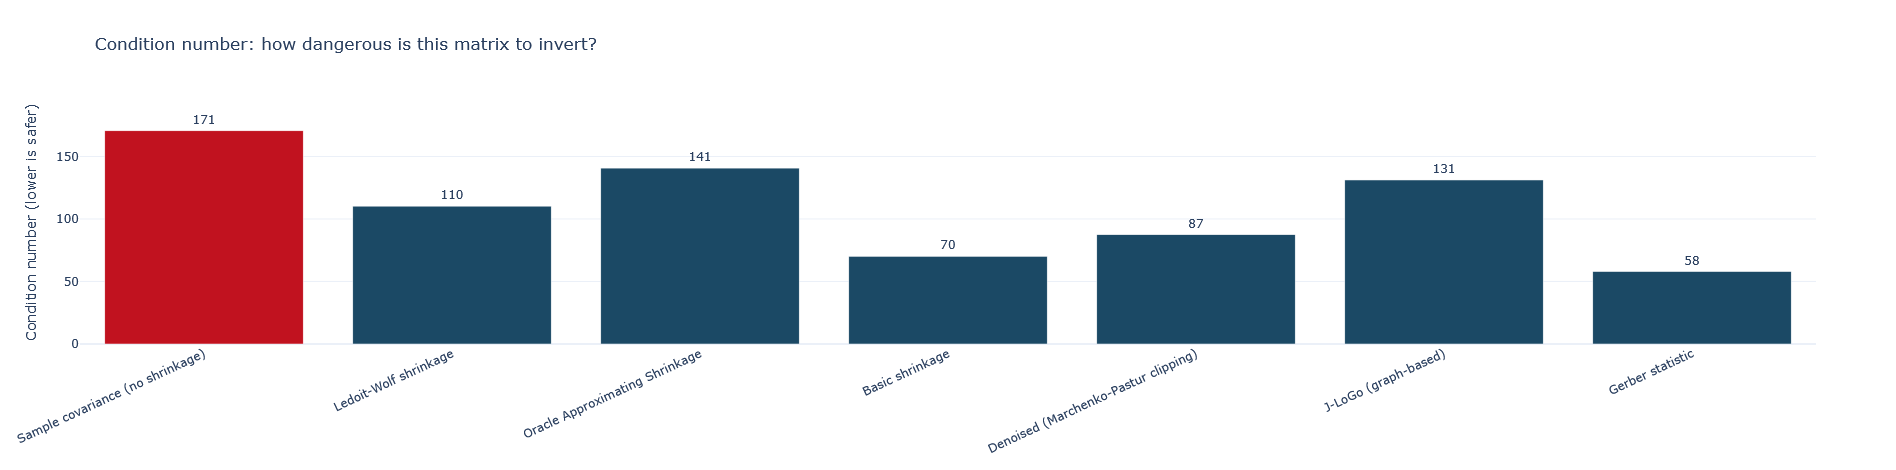

Every shrinkage and denoising method improves the conditioning. Now the real
question: does better conditioning produce better PORTFOLIOS?


In [5]:
if HAS_RISKFOLIO:
    fig = go.Figure(go.Bar(
        x=cov_tbl.index, y=cov_tbl["Condition number"],
        marker_color=[AIRM_COLOURS[1] if i == 0 else AIRM_COLOURS[0]
                      for i in range(len(cov_tbl))],
        text=[f"{v:.0f}" for v in cov_tbl["Condition number"]], textposition="outside"))
    fig.update_layout(
        title="Condition number: how dangerous is this matrix to invert?",
        template=AIRM_TEMPLATE, height=470, showlegend=False,
        yaxis_title="Condition number (lower is safer)", xaxis_tickangle=-25)
    fig.show()
    print("Every shrinkage and denoising method improves the conditioning. Now the real")
    print("question: does better conditioning produce better PORTFOLIOS?")

In [6]:
if HAS_RISKFOLIO:
    # What do the different estimators do to the weights the optimiser chooses?
    def optimise(cov_key, obj="Sharpe"):
        p = rp.Portfolio(returns=train)
        p.assets_stats(method_mu="hist", method_cov=cov_key)
        w = p.optimization(model="Classic", rm="MV", obj=obj, rf=0, l=0, hist=True)
        return None if w is None else w.values.ravel()

    def effective_n(w):
        """Inverse Herfindahl index: how many assets is this portfolio EFFECTIVELY holding?"""
        return 1.0 / np.sum(np.asarray(w) ** 2)

    weight_rows = []
    weight_store = {}
    for key, label in COV_METHODS.items():
        w = optimise(key)
        if w is None: continue
        weight_store[label] = w
        weight_rows.append({"Method": label, "Max weight": w.max(),
                            "Holdings > 1%": int((w > 0.01).sum()),
                            "Effective N": effective_n(w)})
    wtbl = pd.DataFrame(weight_rows).set_index("Method")
    print("What the max-Sharpe optimiser holds under each covariance estimator:\n")
    print(wtbl.to_string(formatters={"Max weight": "{:.1%}".format,
                                     "Holdings > 1%": "{:.0f}".format,
                                     "Effective N": "{:.1f}".format}))
    print(f"\nThere are {N} stocks available. 'Effective N' is 1/sum(w^2) -- the number of")
    print("equally weighted positions that would give the same concentration.")

What the max-Sharpe optimiser holds under each covariance estimator:

                                     Max weight Holdings > 1% Effective N
Method                                                                   
Sample covariance (no shrinkage)          48.6%             6         3.2
Ledoit-Wolf shrinkage                     46.1%             6         3.4
Oracle Approximating Shrinkage            47.6%             6         3.3
Basic shrinkage                           42.7%             6         3.7
Denoised (Marchenko-Pastur clipping)      49.3%             7         3.2
J-LoGo (graph-based)                      39.8%             7         4.2
Gerber statistic                          39.7%             8         4.6

There are 44 stocks available. 'Effective N' is 1/sum(w^2) -- the number of
equally weighted positions that would give the same concentration.


Shrinkage improves the conditioning substantially, and it does moderate the weights — but
look at the "Effective N" column. Even the best-conditioned estimator is still effectively
holding a small handful of the 44 stocks available.

That tells us something important: **shrinking $\Sigma$ is not enough.** The concentration is
being driven by the expected returns $\mu$ as much as by the covariance matrix, and shrinkage
of $\Sigma$ does nothing about that. Which motivates a more radical idea.

---

## 3. Fix two: throw the noise away

If 41 of our 44 eigenvalue directions are indistinguishable from noise, why keep them?

**Denoising** does exactly that. Take the eigendecomposition, find every eigenvalue inside
the Marchenko–Pastur band, and replace them all with their average — preserving the trace
(total variance) while removing the spurious *structure* among the noise directions. What
remains is the handful of real factors plus a clean, isotropic residual.

This is principal component analysis with a statistically principled cut-off, and it is
López de Prado's recommended pre-processing step before any optimisation.

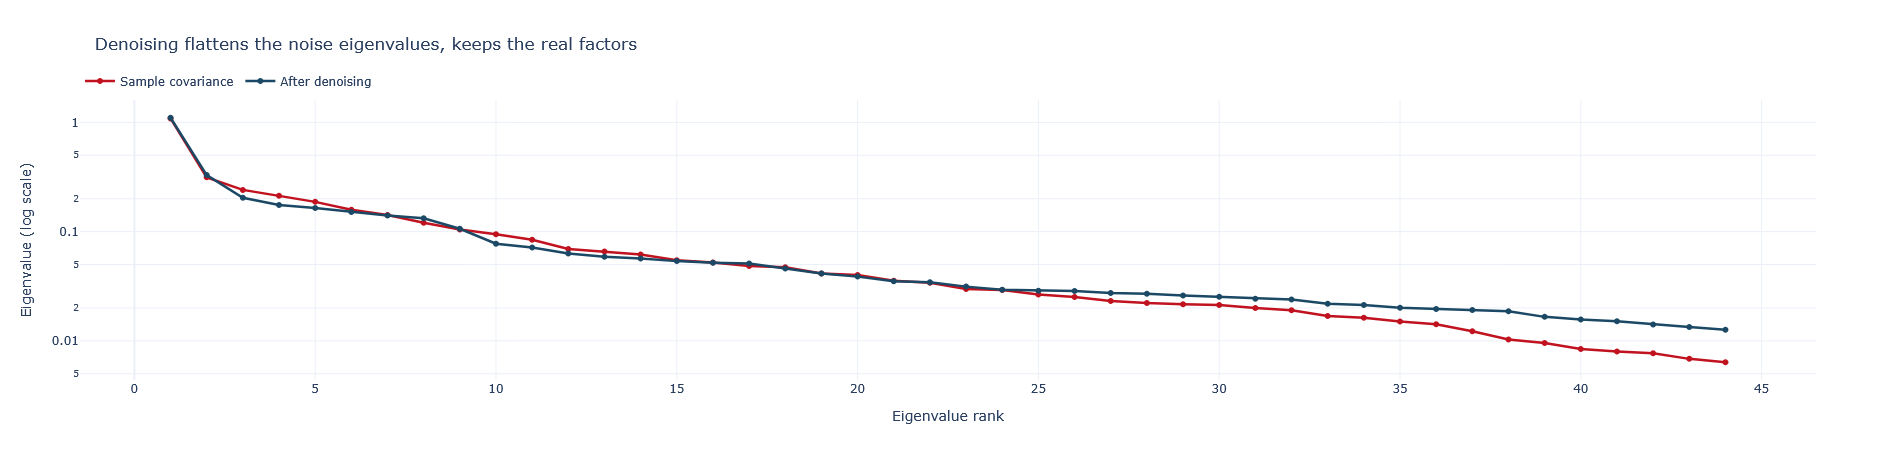

Condition number before denoising: 170.5
Condition number after denoising : 87.4

Total variance (trace) before: 3.6671
Total variance (trace) after : 3.6671   <- preserved

The top few eigenvalues are untouched. The tail has been flattened to a
constant -- we kept the signal and discarded the spurious detail.


In [7]:
if HAS_RISKFOLIO:
    S_sample = train.cov().values * TRADING_DAYS
    S_denoised = af.denoiseCov(S_sample, q=T/N, kind="fixed")

    e_before = np.linalg.eigvalsh(S_sample)[::-1]
    e_after = np.linalg.eigvalsh(S_denoised)[::-1]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=np.arange(1, N+1), y=e_before, mode="lines+markers",
                             name="Sample covariance", line=dict(color=AIRM_COLOURS[1], width=2.5)))
    fig.add_trace(go.Scatter(x=np.arange(1, N+1), y=e_after, mode="lines+markers",
                             name="After denoising", line=dict(color=AIRM_COLOURS[0], width=2.5)))
    fig.update_layout(
        title="Denoising flattens the noise eigenvalues, keeps the real factors",
        template=AIRM_TEMPLATE, height=460, yaxis_type="log",
        xaxis_title="Eigenvalue rank", yaxis_title="Eigenvalue (log scale)",
        legend=dict(orientation="h", y=1.12))
    fig.show()

    print(f"Condition number before denoising: {condition_number(S_sample):.1f}")
    print(f"Condition number after denoising : {condition_number(S_denoised):.1f}")
    print(f"\nTotal variance (trace) before: {np.trace(S_sample):.4f}")
    print(f"Total variance (trace) after : {np.trace(S_denoised):.4f}   <- preserved")
    print("\nThe top few eigenvalues are untouched. The tail has been flattened to a")
    print("constant -- we kept the signal and discarded the spurious detail.")

<details>
<summary><b>A warning about riskfolio's 'spectral' option, and a note on 'detone'</b></summary>

Riskfolio's `denoiseCov` supports three kinds. We use `kind="fixed"`, which replaces the noise
eigenvalues with their average and is the standard method.

Be careful with `kind="spectral"`: it sets the noise eigenvalues to **zero**, which makes the
matrix singular. In version 7.3 this produces a covariance matrix with a condition number
around $10^8$ and riskfolio itself will warn you that the result is not positive definite. It
cannot be inverted, so any mean-variance optimisation on it is meaningless. Use `"fixed"` or
`"shrink"`.

There is also a `detone` option, which additionally removes the *largest* eigenvalue — the
market factor. That sounds appealing for stock selection, since it leaves you with purely
relative information. But be careful: your portfolio still bears market risk whether or not
your covariance matrix models it, so a detoned matrix will systematically understate your
true risk. It is a tool for signal extraction, not risk measurement.

</details>

---

## 4. Fix three: stop inverting altogether

Shrinkage and denoising make the matrix safer to invert. **Hierarchical Risk Parity** asks a
better question: why invert it at all?

López de Prado's HRP replaces matrix inversion with a three-step procedure built on
unsupervised learning:

1. **Cluster.** Convert correlations to distances and build a hierarchical tree of the assets.
2. **Quasi-diagonalise.** Reorder the covariance matrix so that similar assets sit adjacent,
   pushing large covariances towards the diagonal.
3. **Recursively bisect.** Walk down the tree, splitting the allocation between each pair of
   branches in inverse proportion to their risk.

No inversion, no expected returns, and no way to take a huge position in one stock — because
the tree structure forces capital to spread across branches.

First, the clustering. The distance between two assets is
$d_{ij} = \sqrt{\tfrac{1}{2}(1 - \rho_{ij})}$, so perfectly correlated assets sit on top of
each other and uncorrelated ones sit far apart.

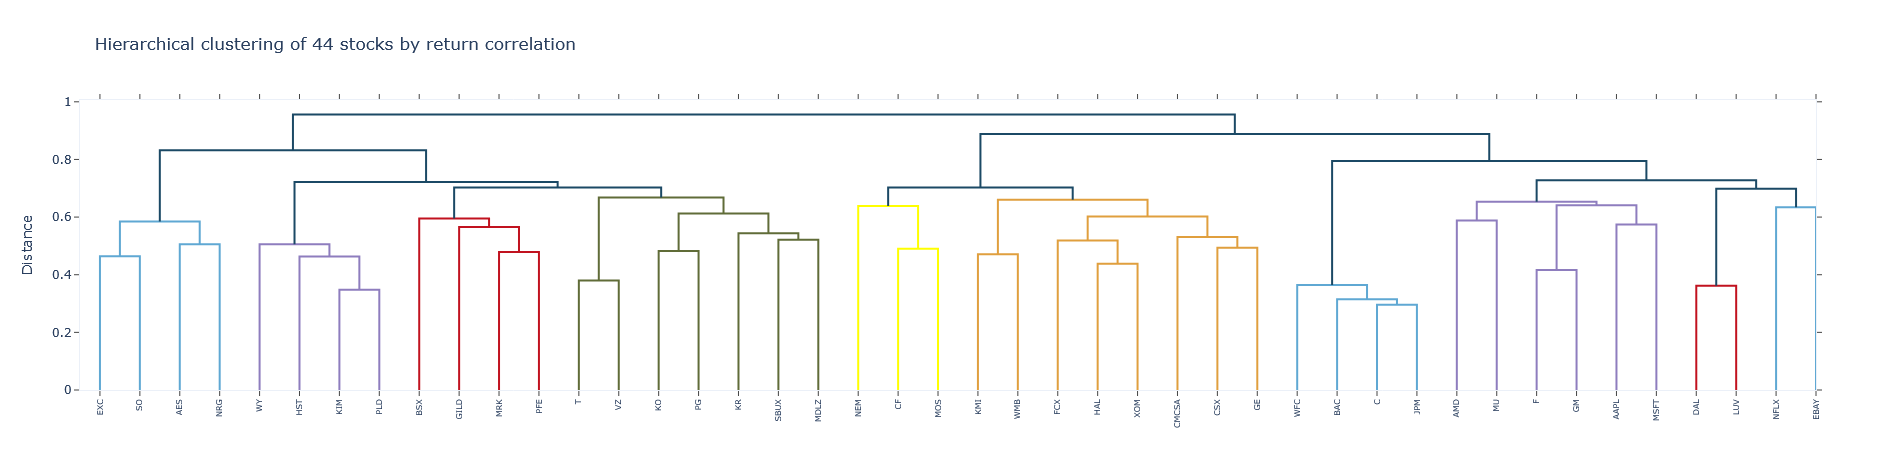

The algorithm has never seen a sector label. It only saw daily returns.


In [8]:
def correlation_distance(corr_matrix):
    """Convert a correlation matrix to a proper distance matrix for clustering."""
    d = np.sqrt(np.clip(0.5 * (1 - corr_matrix), 0, None))
    np.fill_diagonal(d, 0.0)
    return d

corr_df = train.corr()
dist = correlation_distance(corr_df.values)
Z = linkage(squareform(dist, checks=False), method="ward")

fig = ff.create_dendrogram(np.zeros((N, 2)), labels=universe,
                           linkagefun=lambda _: Z, orientation="bottom",
                           colorscale=AIRM_COLOURS)
fig.update_layout(title="Hierarchical clustering of 44 stocks by return correlation",
                  template=AIRM_TEMPLATE, height=470,
                  xaxis=dict(tickangle=-90, tickfont=dict(size=8)),
                  yaxis_title="Distance")
fig.show()

print("The algorithm has never seen a sector label. It only saw daily returns.")

Clusters requested: 11 (the number of GICS sectors)
Adjusted Rand Index vs GICS   : 0.629   (0 = random, 1 = perfect)
Normalised Mutual Information : 0.851

Sectors recovered PERFECTLY (all 4 stocks in one cluster): 7 of 11
   Consumer Staples
   Energy
   Financials
   Health Care
   Information Technology
   Real Estate
   Utilities


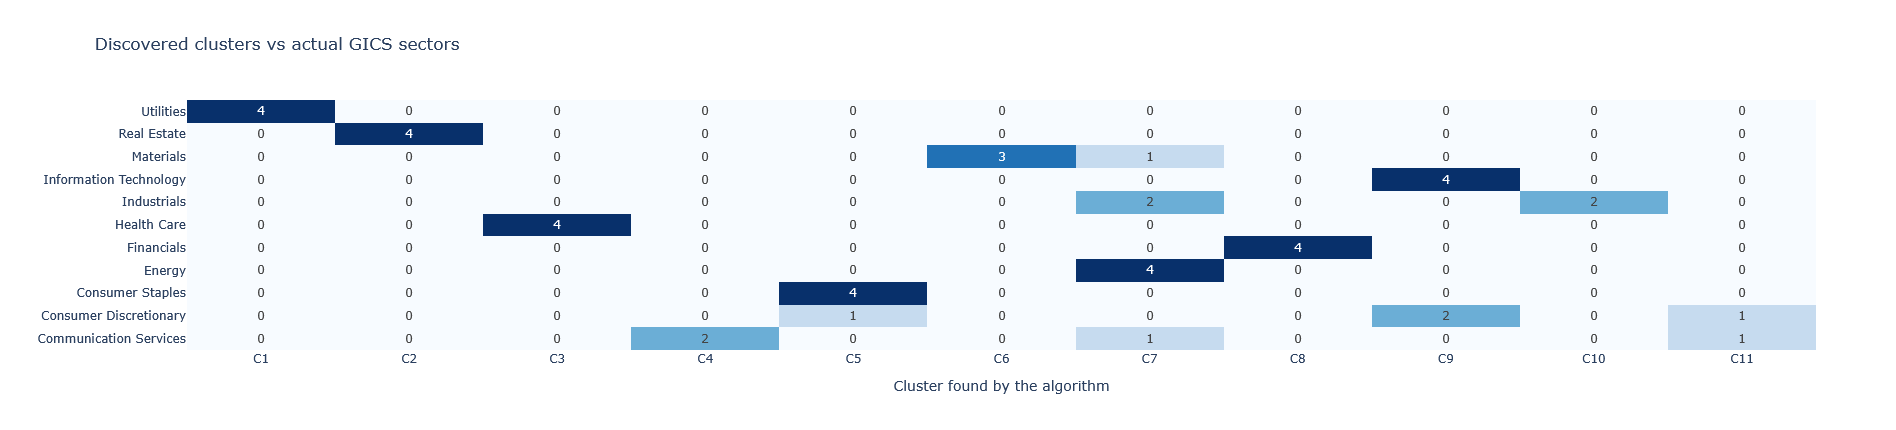

In [9]:
# Did the clustering rediscover the GICS sectors?
n_sectors = len({SECTOR[t] for t in universe})
cluster_labels = fcluster(Z, t=n_sectors, criterion="maxclust")
true_labels = pd.Categorical([SECTOR[t] for t in universe]).codes

ari = adjusted_rand_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)

print(f"Clusters requested: {n_sectors} (the number of GICS sectors)")
print(f"Adjusted Rand Index vs GICS   : {ari:.3f}   (0 = random, 1 = perfect)")
print(f"Normalised Mutual Information : {nmi:.3f}\n")

crosstab = pd.crosstab(pd.Series([SECTOR[t] for t in universe], name="GICS sector"),
                       pd.Series(cluster_labels, name="Discovered cluster"))
perfect = [s for s in crosstab.index if crosstab.loc[s].max() == crosstab.loc[s].sum()]
print(f"Sectors recovered PERFECTLY (all {PER_SECTOR} stocks in one cluster): "
      f"{len(perfect)} of {n_sectors}")
for s in perfect:
    print(f"   {s}")

fig = go.Figure(go.Heatmap(z=crosstab.values, x=[f"C{c}" for c in crosstab.columns],
                           y=crosstab.index, colorscale="Blues",
                           text=crosstab.values, texttemplate="%{text}",
                           showscale=False))
fig.update_layout(title="Discovered clusters vs actual GICS sectors",
                  template=AIRM_TEMPLATE, height=430,
                  xaxis_title="Cluster found by the algorithm", yaxis_title="")
fig.show()

This is the most satisfying result in the notebook. Given nothing but daily returns, the
clustering algorithm recovered **seven of the eleven GICS sectors perfectly** — every
utility grouped together, every energy name, every financial — with an Adjusted Rand Index of
0.63 and normalised mutual information of 0.85 against the official classification.

Two lessons sit inside that.

**The structure is real, not imposed.** In Lecture 3a we ordered the correlation heatmap by
sector and blocks appeared. A sceptic could have said we found what we went looking for. Here
the algorithm was shown no labels at all and found the same structure, which is about as good
an independent confirmation as you get in this field.

**Where it disagrees is interesting, not wrong.** The four it did not recover cleanly —
Communication Services, Consumer Discretionary, Industrials and Materials — are exactly the
economically heterogeneous ones. GICS puts a telecoms utility and a social media company in
the same bucket; correlations do not. Here the algorithm is arguably right and the taxonomy
is the thing that is wrong.

### Building the HRP portfolio

Riskfolio-Lib implements the full procedure. We will also build **NCO** (Nested Clustered
Optimisation), which uses the same tree but runs a small mean-variance optimisation *within*
each cluster and then *across* clusters — a middle road between HRP's total refusal to
optimise and the classic optimiser's total confidence.

In [10]:
if HAS_RISKFOLIO:
    def hierarchical_weights(rets, model="HRP", linkage_method="ward"):
        """HRP or NCO weights. Note HERC is broken in riskfolio 7.3 -- avoid it."""
        h = rp.HCPortfolio(returns=rets)
        w = h.optimization(model=model, codependence="pearson", rm="MV", rf=0,
                           linkage=linkage_method, max_k=10, leaf_order=True)
        return w.values.ravel()

    w_hrp = hierarchical_weights(train, "HRP")
    w_nco = hierarchical_weights(train, "NCO")
    w_ms  = optimise("hist")
    w_eq  = np.ones(N) / N

    compare = pd.DataFrame({
        "Max Sharpe": w_ms, "HRP": w_hrp, "NCO": w_nco, "Equal weight": w_eq},
        index=universe)

    stats_rows = []
    for col in compare.columns:
        w = compare[col].values
        stats_rows.append({"Portfolio": col, "Max weight": w.max(),
                           "Min weight": w.min(), "Holdings > 1%": int((w > 0.01).sum()),
                           "Effective N": effective_n(w)})
    print(pd.DataFrame(stats_rows).set_index("Portfolio").to_string(
        formatters={"Max weight": "{:.1%}".format, "Min weight": "{:.2%}".format,
                    "Holdings > 1%": "{:.0f}".format, "Effective N": "{:.1f}".format}))
    print(f"\nOut of {N} available stocks:")
    print(f"  the classic optimiser is effectively holding {effective_n(w_ms):.1f}")
    print(f"  HRP is effectively holding {effective_n(w_hrp):.1f}")
    print("\nHRP has no mechanism for taking a large bet. The tree will not let it.")

             Max weight Min weight Holdings > 1% Effective N
Portfolio                                                   
Max Sharpe        48.6%      0.00%             6         3.2
HRP                6.0%      0.40%            35        32.2
NCO               20.4%      0.00%            16         9.1
Equal weight       2.3%      2.27%            44        44.0

Out of 44 available stocks:
  the classic optimiser is effectively holding 3.2
  HRP is effectively holding 32.2

HRP has no mechanism for taking a large bet. The tree will not let it.


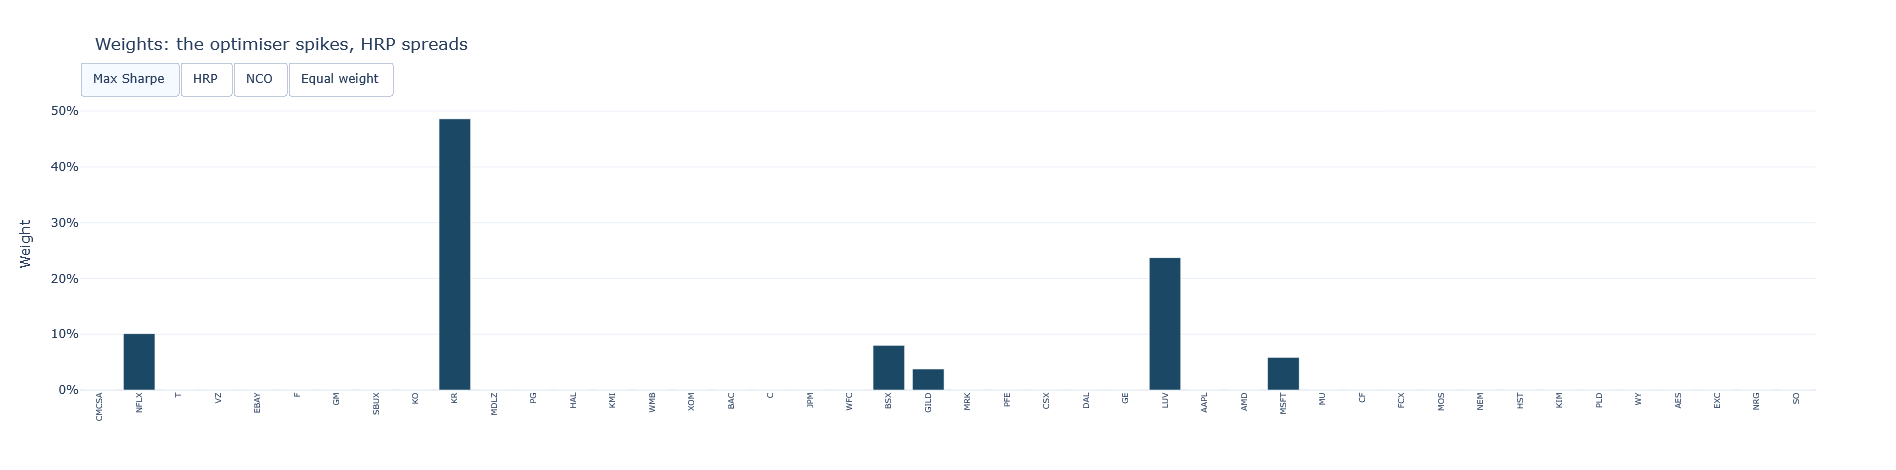

In [12]:
if HAS_RISKFOLIO:
    fig = go.Figure()
    for i, col in enumerate(["Max Sharpe", "HRP", "NCO", "Equal weight"]):
        fig.add_trace(go.Bar(x=universe, y=compare[col], name=col,
                             marker_color=AIRM_COLOURS[i], visible=(i == 0)))
    fig.update_layout(
        title="Weights: the optimiser spikes, HRP spreads",
        template=AIRM_TEMPLATE, height=470, showlegend=False,
        yaxis=dict(title="Weight", tickformat=".0%", range=[0, 0.52]),
        xaxis=dict(tickangle=-90, tickfont=dict(size=8)),
        updatemenus=[dict(type="buttons", direction="right", x=0, y=1.13, xanchor="left",
            buttons=[dict(label=c, method="update",
                          args=[{"visible": [j == i for j in range(4)]}])
                     for i, c in enumerate(["Max Sharpe", "HRP", "NCO", "Equal weight"])])])
    fig.show()

---

## 5. The horse race

Now we judge them properly. Everything so far compared portfolios built once on the training
set. That is not how anyone invests.

Instead: walk forward through time. Every month, estimate on the trailing year, build the
portfolio, hold it for a month, pay 20 basis points on whatever we traded, and roll on. This
is the protocol that decides whether a method is real.

A one-year lookback on 44 stocks means $T/N = 5.7$ — the hard regime where the noise ceiling
sits high and shrinkage should matter most. That is deliberate. It is also entirely realistic.

In [13]:
if HAS_RISKFOLIO:
    LOOKBACK, HOLD, COST_BPS = 252, 21, 20

    def build_portfolio(method, rets_window):
        """Dispatch to whichever construction method we are testing."""
        n = rets_window.shape[1]
        if method == "Equal weight":
            return np.ones(n) / n
        if method == "Inverse vol":
            iv = 1 / rets_window.std().values
            return iv / iv.sum()
        if method in ("HRP", "NCO"):
            return hierarchical_weights(rets_window, method)
        cov_key = {"Max Sharpe": "hist", "Max Sharpe + Ledoit": "ledoit",
                   "Max Sharpe + denoised": "fixed", "Min variance": "hist"}[method]
        p = rp.Portfolio(returns=rets_window)
        p.assets_stats(method_mu="hist", method_cov=cov_key)
        obj = "MinRisk" if method == "Min variance" else "Sharpe"
        w = p.optimization(model="Classic", rm="MV", obj=obj, rf=0, l=0, hist=True)
        return np.ones(n) / n if w is None else w.values.ravel()

    METHODS = ["Equal weight", "Inverse vol", "Min variance", "Max Sharpe",
               "Max Sharpe + Ledoit", "Max Sharpe + denoised", "HRP", "NCO"]

    rebal_dates = list(range(LOOKBACK, len(returns) - HOLD, HOLD))
    track = {m: {"ret": [], "turnover": []} for m in METHODS}

    print(f"Running {len(METHODS)} methods x {len(rebal_dates)} rebalances ...")
    for method in METHODS:
        w_prev = None
        for s0 in rebal_dates:
            window = returns.iloc[s0 - LOOKBACK:s0]
            try:
                w = build_portfolio(method, window)
            except Exception:
                w = np.ones(N) / N
            w = np.nan_to_num(w)
            w = w / w.sum()
            turnover = 0.0 if w_prev is None else np.abs(w - w_prev).sum()
            w_prev = w
            period = returns.iloc[s0:s0 + HOLD].values @ w
            period = period.copy()
            period[0] -= turnover * COST_BPS / 1e4     # charge costs on day one
            track[method]["ret"] += list(period)
            track[method]["turnover"].append(turnover)
    print("done.")

Running 8 methods x 47 rebalances ...
done.


In [14]:
if HAS_RISKFOLIO:
    def summarise(daily):
        r = np.asarray(daily)
        curve = (1 + r).cumprod()
        return {"CAGR": curve[-1] ** (TRADING_DAYS/len(r)) - 1,
                "Volatility": r.std() * np.sqrt(TRADING_DAYS),
                "Sharpe": r.mean() / r.std() * np.sqrt(TRADING_DAYS),
                "Max drawdown": (curve / np.maximum.accumulate(curve) - 1).min()}

    race = []
    for m in METHODS:
        s = summarise(track[m]["ret"])
        s["Portfolio"] = m
        s["Avg turnover"] = np.mean(track[m]["turnover"])
        race.append(s)
    race_df = pd.DataFrame(race).set_index("Portfolio").sort_values("Sharpe", ascending=False)

    race_df[["CAGR", "Volatility", "Sharpe", "Max drawdown", "Avg turnover"]].style.format(
        {"CAGR": "{:.2%}", "Volatility": "{:.2%}", "Sharpe": "{:.2f}",
         "Max drawdown": "{:.1%}", "Avg turnover": "{:.2f}"}).background_gradient(
        subset=["Sharpe"], cmap="RdYlGn")

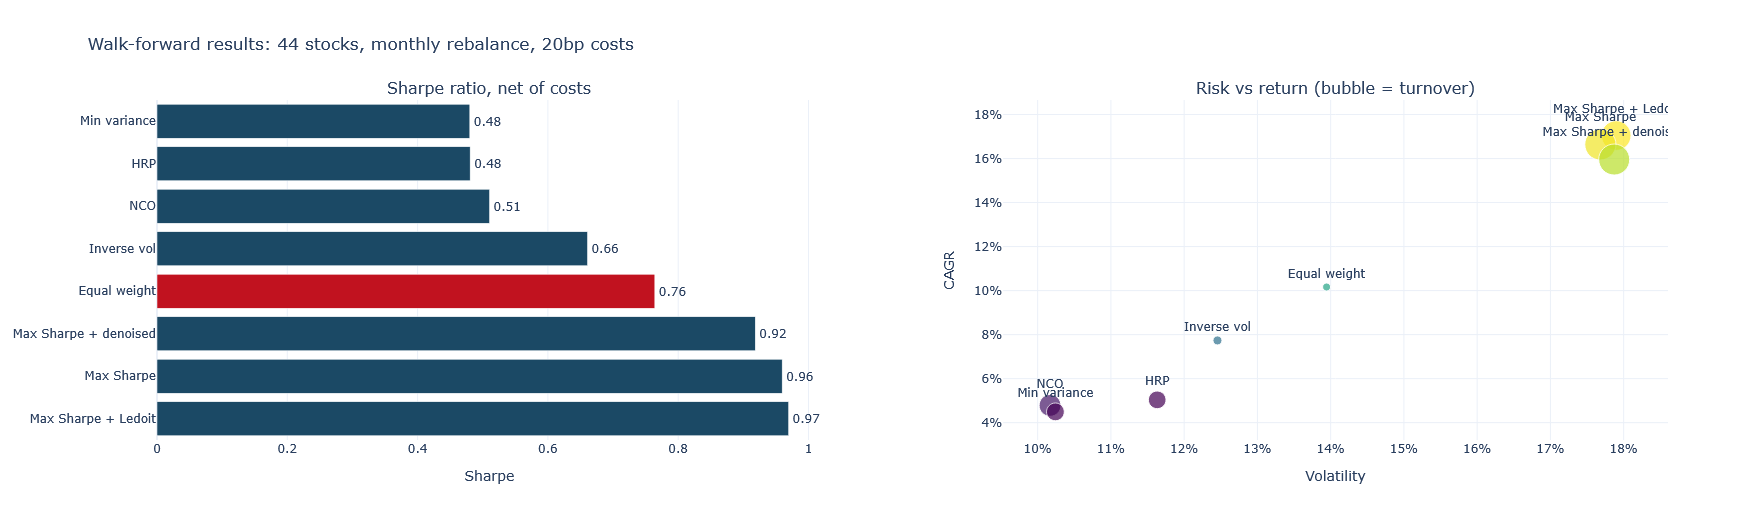

In [15]:
if HAS_RISKFOLIO:
    fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.12,
        subplot_titles=("Sharpe ratio, net of costs", "Risk vs return (bubble = turnover)"))
    ordered = race_df.index.tolist()
    fig.add_trace(go.Bar(y=ordered, x=race_df["Sharpe"], orientation="h",
                         marker_color=[AIRM_COLOURS[1] if m == "Equal weight"
                                       else AIRM_COLOURS[0] for m in ordered],
                         text=[f"{v:.2f}" for v in race_df["Sharpe"]],
                         textposition="outside", showlegend=False), 1, 1)
    fig.add_trace(go.Scatter(x=race_df["Volatility"], y=race_df["CAGR"], mode="markers+text",
                             text=ordered, textposition="top center",
                             marker=dict(size=8 + 40*race_df["Avg turnover"],
                                         color=race_df["Sharpe"], colorscale="Viridis",
                                         showscale=False, line=dict(color="white", width=1)),
                             showlegend=False), 1, 2)
    fig.update_xaxes(title_text="Sharpe", row=1, col=1)
    fig.update_xaxes(title_text="Volatility", tickformat=".0%", row=1, col=2)
    fig.update_yaxes(title_text="CAGR", tickformat=".0%", row=1, col=2)
    fig.update_layout(template=AIRM_TEMPLATE, height=520,
                      title="Walk-forward results: 44 stocks, monthly rebalance, 20bp costs")
    fig.show()

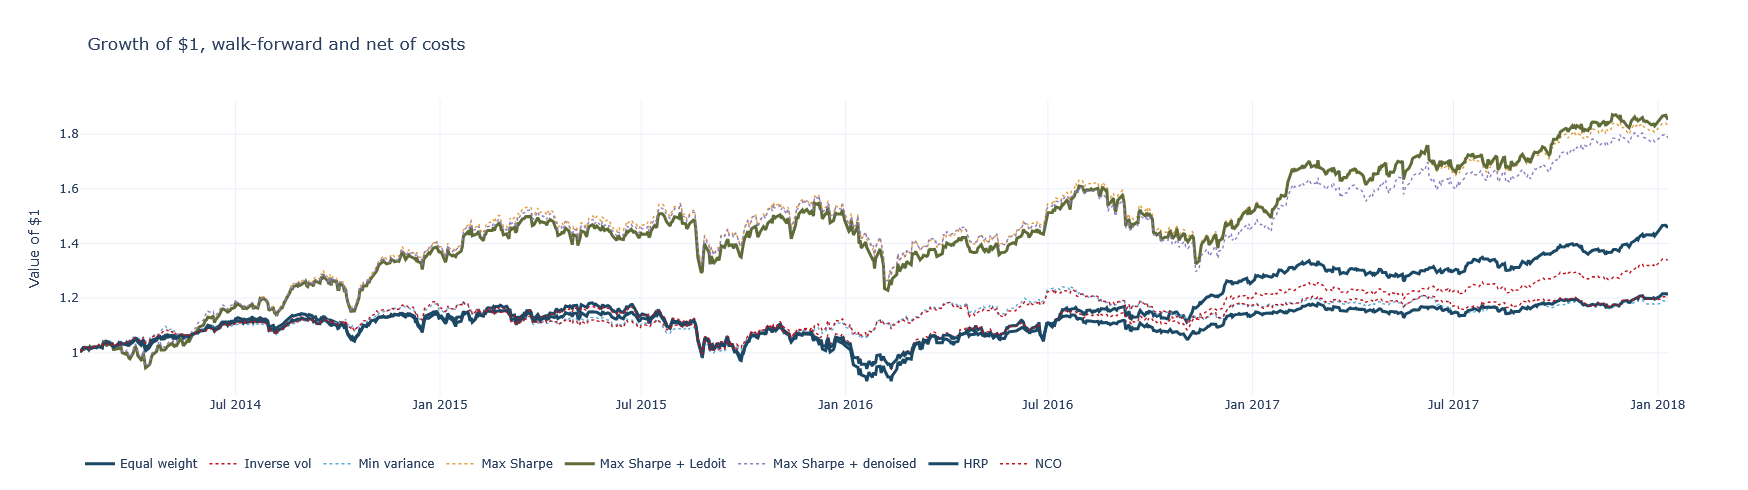

In [16]:
if HAS_RISKFOLIO:
    fig = go.Figure()
    highlight = {"Equal weight", "Max Sharpe + Ledoit", "HRP"}
    for i, m in enumerate(METHODS):
        curve = (1 + np.asarray(track[m]["ret"])).cumprod()
        idx = returns.index[LOOKBACK:LOOKBACK + len(curve)]
        fig.add_trace(go.Scatter(x=idx, y=curve, name=m,
                                 line=dict(width=3 if m in highlight else 1.4,
                                           dash=None if m in highlight else "dot",
                                           color=AIRM_COLOURS[i % len(AIRM_COLOURS)])))
    fig.update_layout(title="Growth of $1, walk-forward and net of costs",
                      template=AIRM_TEMPLATE, height=490, hovermode="x unified",
                      yaxis_title="Value of $1", legend=dict(orientation="h", y=-0.18))
    fig.show()

### Reading the result honestly

Three things are true at once here, and a good analyst reports all three.

**Shrinkage helped, slightly and consistently.** Ledoit–Wolf shrinkage produced the best
Sharpe in the race, edging out the plain sample covariance. The margin is small — well within
what 47 rebalances can resolve — but it came for free, from one changed argument, and it is
the direction the theory predicts.

**Denoising did not help here.** It improved the conditioning and then slightly *reduced*
Sharpe. That is a real result, not a bug: the eigenvalues it discarded were mostly noise, but
"mostly" is not "entirely", and on this universe the small amount of signal thrown away cost
more than the noise removed. Denoising tends to pay off in the wide, short-history regime it
was designed for — hundreds of assets, not 44.

**HRP did not win on Sharpe, but it delivered exactly what it promises.** Look at the other
columns rather than the ranking. HRP ran at 11.6% volatility against the optimiser's 17.7% —
a third less risk. NCO produced the shallowest drawdown of any method at −16.3%, against
−24.2% for equal weight. HRP traded **less than half** as much as the classic optimiser
(turnover 0.24 versus 0.58), which matters enormously once costs are realistic. And HRP held
an effective **24** stocks where the optimiser held 10. If your objective is genuine
diversification and low trading, HRP delivered it. If your objective was the highest Sharpe in
a strong bull market, deviating from a broad basket was always going to cost you.

That last point deserves emphasis, because it is where students most often misread a table
like this. **A method that loses on Sharpe has not necessarily failed.** It has optimised
something else, and you have to check whether that something else is what you wanted.

---

## 6. The finding that matters more than any of the methods

Now compare across notebooks, because this is the real punchline of Lecture 3.

| | Max Sharpe | Equal weight |
|---|---|---|
| **Lecture 3b**: one split, weights frozen for two years | 0.76 | **1.82** |
| **Lecture 3c**: monthly re-estimation, after costs | **0.96** | 0.76 |

The same optimiser, on the same 44 stocks, over the same five years of data. In one protocol
it is crushed by equal weighting; in the other it beats it.

Nothing about the method changed. What changed was **how often it was allowed to update its
estimates**. Freezing weights for two years let the estimation error compound; re-estimating
monthly let stale, unlucky positions wash out.

The effect of that single design choice is larger than the effect of every shrinkage and
clustering technique in this notebook combined.

This is the thread running through the whole course. In Lecture 2, data construction mattered
more than model choice. In Lecture 2's supplement, the metric mattered more than the
architecture. Here, the rebalancing protocol matters more than the estimator. **The
scaffolding around a model routinely dominates the model.** Lecture 5 makes this the explicit
subject.

<details>
<summary><b>How confident should we be in any of these numbers?</b></summary>

Not very, and it is important to say so. With 47 rebalances and roughly four years of
out-of-sample data, the standard error on a Sharpe estimate is approximately
$\sqrt{(1 + S^2/2)/T_{\text{years}}} \approx 0.55$.

Nearly every difference in the horse race table is smaller than that. So the honest reading
is not "Ledoit–Wolf shrinkage is the best method" but "shrinkage was not worse, and the theory
says it should help, so it is a reasonable default." The protocol comparison above is a larger
effect and rests on firmer ground, but even it is one path through one market.

This is not a counsel of despair — it is what competent quantitative research looks like.
Report the effect, report the uncertainty, and be suspicious of anyone who does not.

</details>

---

## 7. Beyond variance: other risk measures and real constraints

One last practical piece, carried over from the classical toolkit. Variance punishes upside
and downside equally, which few investors actually want. Riskfolio-Lib will optimise against
a dozen alternatives; the important ones are:

- **CVaR** (Conditional Value at Risk): the average loss in the worst $\alpha$% of cases.
- **CDaR** (Conditional Drawdown at Risk): the same idea applied to drawdowns.
- **MAD** (Mean Absolute Deviation): less sensitive to outliers than variance.

And real mandates come with constraints — sector caps, position limits — which we saw in
Lecture 3b are not an inconvenience but a *benefit*.

In [17]:
if HAS_RISKFOLIO:
    risk_measures = {"MV": "Variance", "MAD": "Mean absolute deviation",
                     "CVaR": "Conditional VaR (95%)", "CDaR": "Conditional drawdown at risk"}
    p = rp.Portfolio(returns=train)
    p.assets_stats(method_mu="hist", method_cov="ledoit")

    rm_weights, rm_rows = {}, []
    for rm, label in risk_measures.items():
        try:
            w = p.optimization(model="Classic", rm=rm, obj="Sharpe", rf=0, l=0, hist=True)
            if w is None: continue
            wv = w.values.ravel()
            rm_weights[label] = wv
            _, _, _ = None, None, None
            r = returns.iloc[split_k:].values @ wv
            rm_rows.append({"Risk measure": label,
                            "Effective N": effective_n(wv), "Max weight": wv.max(),
                            "OOS Sharpe": r.mean()/r.std()*np.sqrt(TRADING_DAYS)})
        except Exception as e:
            print(f"  {label}: failed ({type(e).__name__})")
    print(pd.DataFrame(rm_rows).set_index("Risk measure").to_string(
        formatters={"Effective N": "{:.1f}".format, "Max weight": "{:.1%}".format,
                    "OOS Sharpe": "{:.2f}".format}))
    print("\nDifferent definitions of 'risk' produce genuinely different portfolios.")
    print("Choosing the risk measure is an investment decision, not a technical detail.")

                             Effective N Max weight OOS Sharpe
Risk measure                                                  
Variance                             3.4      46.1%       0.83
Mean absolute deviation              3.0      52.9%       0.71
Conditional VaR (95%)                2.5      55.3%       0.56
Conditional drawdown at risk         4.1      33.0%       0.90

Different definitions of 'risk' produce genuinely different portfolios.
Choosing the risk measure is an investment decision, not a technical detail.


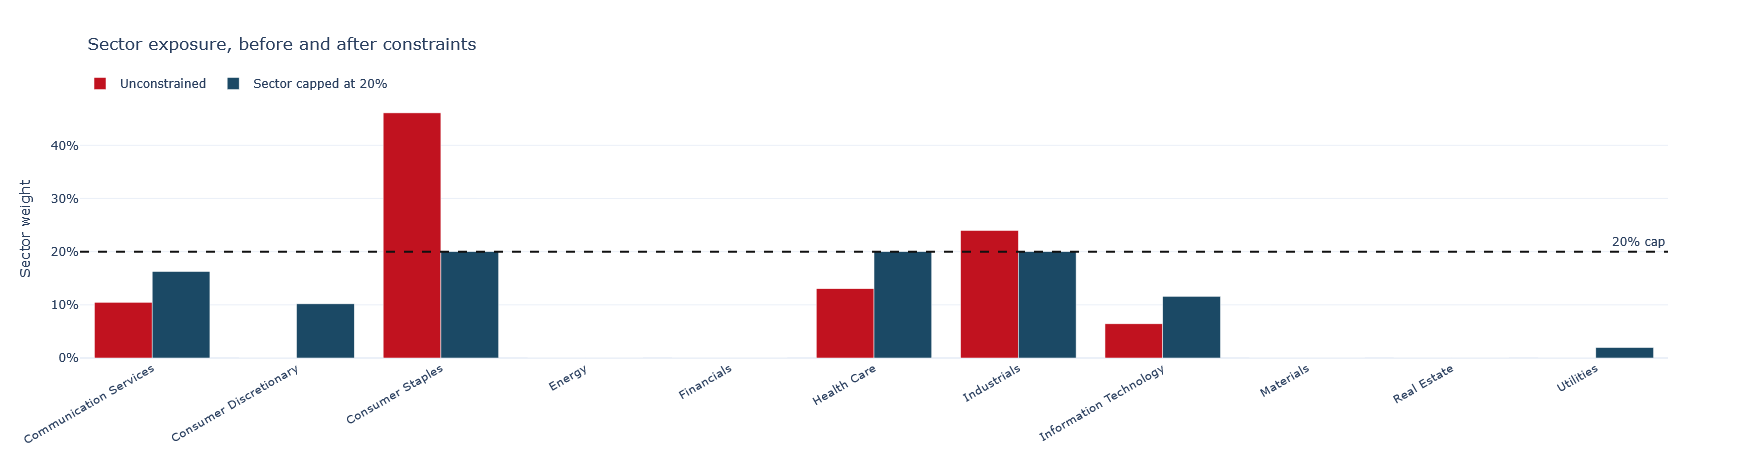

Unconstrained: largest sector 46.1%, effective N 3.4
Constrained  : largest sector 20.0%, effective N 7.1
Constrained out-of-sample Sharpe: 1.48


In [18]:
if HAS_RISKFOLIO:
    # Sector constraints: cap any single GICS sector at 20% of the portfolio.
    asset_classes = pd.DataFrame({"Assets": universe,
                                  "Industry": [SECTOR[t] for t in universe]})
    constraints = pd.DataFrame({
        "Disabled": [False], "Type": ["All Classes"], "Set": ["Industry"],
        "Position": [""], "Sign": ["<="], "Weight": [0.20],
        "Type Relative": [""], "Relative Set": [""], "Relative": [""], "Factor": [""]})

    A, B = rp.assets_constraints(constraints, asset_classes)
    p_con = rp.Portfolio(returns=train)
    p_con.assets_stats(method_mu="hist", method_cov="ledoit")
    p_con.ainequality, p_con.binequality = A, B
    w_con = p_con.optimization(model="Classic", rm="MV", obj="Sharpe", rf=0, l=0, hist=True)

    if w_con is not None:
        wc = w_con.values.ravel()
        by_sector = pd.Series(wc, index=universe).groupby(
            pd.Series([SECTOR[t] for t in universe], index=universe)).sum()
        unc = pd.Series(optimise("ledoit"), index=universe).groupby(
            pd.Series([SECTOR[t] for t in universe], index=universe)).sum()

        fig = go.Figure()
        fig.add_trace(go.Bar(x=unc.index, y=unc.values, name="Unconstrained",
                             marker_color=AIRM_COLOURS[1]))
        fig.add_trace(go.Bar(x=by_sector.index, y=by_sector.values, name="Sector capped at 20%",
                             marker_color=AIRM_COLOURS[0]))
        fig.add_hline(y=0.20, line=dict(color="#111", dash="dash", width=2),
                      annotation_text="20% cap")
        fig.update_layout(title="Sector exposure, before and after constraints",
                          template=AIRM_TEMPLATE, height=460, barmode="group",
                          yaxis=dict(title="Sector weight", tickformat=".0%"),
                          xaxis_tickangle=-30, legend=dict(orientation="h", y=1.12))
        fig.show()

        r_c = returns.iloc[split_k:].values @ wc
        print(f"Unconstrained: largest sector {unc.max():.1%}, effective N {effective_n(optimise('ledoit')):.1f}")
        print(f"Constrained  : largest sector {by_sector.max():.1%}, effective N {effective_n(wc):.1f}")
        print(f"Constrained out-of-sample Sharpe: {r_c.mean()/r_c.std()*np.sqrt(TRADING_DAYS):.2f}")

---

## 8. The verdict

> **"AI fixes the optimiser."**

**It helps, modestly and honestly — and it is not the biggest lever.**

What the machine learning genuinely bought us:

- **A diagnosis.** Marchenko–Pastur told us precisely how much of our covariance matrix was
  noise: 41 of 44 directions. You cannot fix a problem you cannot measure, and this is a
  measurement.
- **Better conditioning.** Shrinkage cut the condition number substantially and gave the best
  Sharpe in the walk-forward race. Small, free, theoretically motivated — take it.
- **Real diversification.** HRP held an effective 24 stocks against the optimiser's 10, at
  less than half the turnover and a third less volatility. It cannot take a reckless bet by
  construction.
- **Independent confirmation of economic structure.** Clustering recovered seven of eleven
  GICS sectors from returns alone, with no labels.

What it did not buy us:

- **A dramatic Sharpe improvement.** Nothing here transformed the results, and the differences
  are within the noise of a four-year test.
- **Escape from the fundamental problem.** Expected returns remain nearly unknowable. Every
  method here works on $\Sigma$; none of them can tell you which stock will go up.

### What breaks in production

**Estimation windows are a choice you cannot avoid making.** We used a year. Shorter is more
responsive and noisier; longer is more stable and staler. There is no correct answer and the
choice matters more than the estimator.

**Correlations move.** Everything here assumed one correlation structure per window. In a
crisis, correlations converge towards one and every diversification benefit evaporates
precisely when needed. Lecture 6 confronts this.

**Costs here were a flat 20bp.** Real costs scale with size and urgency, and they punish the
high-turnover methods far harder than a flat charge suggests.

**Backtest overfitting.** We compared eight methods on one dataset and reported the winner.
Do that often enough and you will find a "winner" from noise alone. Lecture 5 is about how
badly this goes.

**HERC is broken in Riskfolio-Lib 7.3.** A practical note: `model="HERC"` raises a
`TypeError` in this version, which is why it is absent above. Always verify that a library
function works before building a lecture — or a trading system — on top of it.

---

## 9. Exercises

### Core

**C1 — How much is noise?** Change `PER_SECTOR` to 8 (88 stocks) and re-run Section 1. What
happens to $T/N$, to the noise ceiling, and to the number of signal eigenvalues? Explain why
larger universes are *harder*, not easier.

**C2 — Shrink towards what?** Ledoit–Wolf shrinks towards a constant-correlation target.
Compare `ledoit`, `oas` and `shrunk` in the horse race. Do the differences between shrinkage
methods matter as much as the difference between shrinking and not shrinking?

**C3 — Does HRP need the right number of clusters?** Re-run `hierarchical_weights` with
`max_k` set to 4 and then 20. How sensitive are the HRP weights? What does that tell you about
how much of HRP's robustness comes from clustering versus from simply refusing to concentrate?

**C4 — Change the linkage.** Try `linkage_method` of `"single"`, `"complete"` and `"average"`
instead of `"ward"`. Which produces the most balanced tree, and which recovers GICS sectors
best?

### Stretch

**S1 — The protocol experiment.** Section 6 claims the rebalancing frequency mattered more
than the estimator. Test it: run the horse race with `HOLD` set to 5, 21, 63 and 252 days and
plot Sharpe against rebalancing frequency for each method. Is the protocol effect larger than
the spread between methods? Include costs, which will fight back.

**S2 — Denoising where it should work.** Denoising underperformed on 44 stocks. Build a
universe of 200+ stocks with a 252-day window (so $T/N \approx 1.3$) and re-run the
comparison. Does denoising earn its keep in the regime it was designed for?

**S3 — Shrink the means instead.** Every method here shrinks $\Sigma$. Implement
James–Stein shrinkage of $\mu$ towards the cross-sectional average return, and add it to the
horse race. Given Lecture 3b's finding about concentration, would you expect this to help more
or less than shrinking $\Sigma$?

**S4 — Statistical significance.** Using the daily return series in `track`, test whether the
best method's Sharpe is significantly different from equal weight's, using a bootstrap over
the out-of-sample period. How many years of data would you need to distinguish a Sharpe of
0.96 from 0.76 at 95% confidence?

**S5 — A better objective.** Re-run the race optimising CVaR rather than variance at each
rebalance. Does a downside-focused risk measure survive walk-forward testing better than
variance, particularly on maximum drawdown?

---

## Summary

| | |
|---|---|
| **The claim** | "AI fixes the optimiser" |
| **The verdict** | It measures the problem precisely and helps modestly; the evaluation protocol mattered more |
| **The numbers** | 41 of 44 eigenvalue directions are noise. HRP effective N of 24 vs the optimiser's 10, at less than half the turnover. Max Sharpe scored 0.76 frozen, 0.96 re-estimated monthly |

1. **Marchenko–Pastur quantifies the damage.** Only 3 of 44 eigenvalues cleared the noise
   ceiling, while we estimated 990 parameters from 754 observations.
2. **Shrinkage is a free, principled default.** Best Sharpe in the walk-forward race, from one
   changed argument.
3. **Denoising helped conditioning but not returns here** — an honest negative result, and a
   pointer to the regime where it does pay.
4. **Clustering recovered seven of eleven GICS sectors** from returns alone, confirming that
   the structure Lecture 3a drew by hand is genuinely there.
5. **HRP wins on what it optimises**: diversification, drawdown and turnover — not Sharpe.
   Judge a method against its own objective.
6. **The protocol beat the methods.** Re-estimating monthly rather than freezing weights moved
   Sharpe from 0.76 to 0.96, a larger effect than any estimator in this notebook.

**Next**, Lecture 4 turns from constructing one portfolio to constructing them for thousands
of individual clients — robo-advisers, goal-based investing, and the question of how much of
their value is allocation and how much is simply keeping people invested.